In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
col_list = ['Glucose','BloodPressure', 'SkinThickness', 'BMI','Insulin']

In [8]:
for i in col_list:
    df[i] = df[i].replace(0 ,np.NaN)
    mean = int(df[i].mean(skipna= True))
    df[i] = df[i].replace(np.NaN, mean)

In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,155.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,155.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,155.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [10]:
x = df.iloc[: , :8]
y = df.iloc[: , 8]

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train, y_test = train_test_split(x , y , test_size = 0.2 , random_state = 0)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
k_range = range(1, 20)
scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    accuracy = model.score(x_test, y_test)
    scores.append(accuracy)
    print('k = %d, accuracy = %.2f%%' % (k, accuracy * 100))

k = 1, accuracy = 65.58%
k = 2, accuracy = 72.08%
k = 3, accuracy = 72.73%
k = 4, accuracy = 76.62%
k = 5, accuracy = 75.32%
k = 6, accuracy = 76.62%
k = 7, accuracy = 75.97%
k = 8, accuracy = 76.62%
k = 9, accuracy = 75.32%
k = 10, accuracy = 75.32%
k = 11, accuracy = 75.97%
k = 12, accuracy = 75.97%
k = 13, accuracy = 78.57%
k = 14, accuracy = 79.22%
k = 15, accuracy = 77.27%
k = 16, accuracy = 75.32%
k = 17, accuracy = 76.62%
k = 18, accuracy = 76.62%
k = 19, accuracy = 78.57%


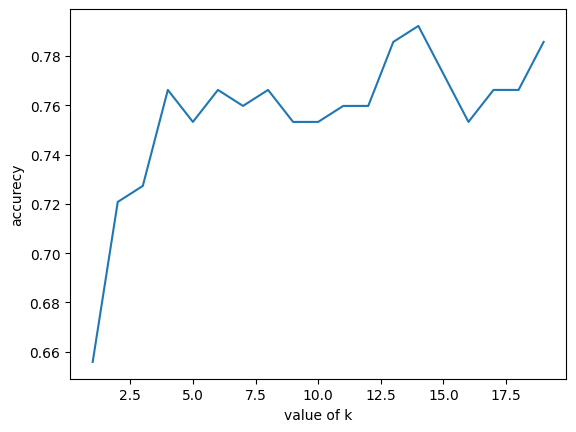

In [14]:
plt.plot(k_range, scores)
plt.xlabel("value of k")
plt.ylabel("accurecy")
plt.show()

In [17]:
model = KNeighborsClassifier(n_neighbors=14, metric='euclidean')
model.fit(x_train, y_train)

,n_neighbors,14
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [18]:
model.score(x_test , y_test)

0.7922077922077922

In [19]:
model.predict([[1,189,60,23,846,30.1 ,0.398, 59]])

array([1], dtype=int64)